<a href="https://colab.research.google.com/github/fatiimaaaa/ML/blob/master/Fracture_Healing_Bayesian_GP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bone Fracture Healing: Bayesian Sigmoidal (Gompertz) + Gaussian Process Model

This notebook:
1. Installs required packages
2. Asks you to **upload `Fracture.xlsx`** (just that one file — from `Dataset/fracture/Fracture.xlsx` in your zip, not the whole folder)
3. Extracts a per-image **severity score** from the real VQA QA labels (crack count, "displaced"/"severe"/"comminuted" mentions)
4. Builds a **semi-synthetic longitudinal RUST-like healing dataset** (one trajectory per real image, conditioned on that image's severity score, calibrated to RUST-literature anchors)
5. Fits a **Bayesian Gompertz healing curve** (explicit MCMC via `emcee`) + a **Gaussian Process residual layer**, for one example patient per outcome class (normal / delayed / nonunion)
6. Shows and saves a figure with the fitted curves + uncertainty bands

> **Important:** the longitudinal dataset generated here is a literature-calibrated **simulation** conditioned on real severity features extracted from your dataset — it is **not** real patient healing data. State this explicitly in any write-up. All calibration choices and modeling assumptions are documented in the comments of each cell.

## 1. Install packages

In [ ]:
%pip install -q openpyxl numpy pandas scikit-learn matplotlib emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.1 MB/s eta 0:00:00


## 2. Upload `Fracture.xlsx`

Run this cell, then use the file picker to upload **only** `Fracture.xlsx` (found inside `Dataset/fracture/Fracture.xlsx` in your zip). You do not need to upload the images or the whole folder — this notebook only reads the QA label spreadsheet.

In [ ]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

FRACTURE_XLSX_PATH = "Fracture.xlsx"

if IN_COLAB and not os.path.exists(FRACTURE_XLSX_PATH):
    from google.colab import files
    print("Please upload your Fracture.xlsx file:")
    uploaded = files.upload()
    FRACTURE_XLSX_PATH = list(uploaded.keys())[0]
elif not os.path.exists(FRACTURE_XLSX_PATH):
    FRACTURE_XLSX_PATH = input(f"Enter path to Fracture.xlsx: ").strip()

print("Using file:", FRACTURE_XLSX_PATH)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Please upload your Fracture.xlsx file:


Saving Fracture.xlsx to Fracture.xlsx
Using file: Fracture.xlsx


## 3. Severity extraction from the real VQA labels

This is the genuine, defensible link between your real dataset and the synthetic healing-curve model below: we are **not**
inventing healing-stage images (none exist in this dataset — it's single-timepoint acute fracture X-rays only). We **are**
extracting a severity signal that already exists in the QA labels (crack counts, "displaced"/"severe"/"comminuted" mentions)
and using it as a covariate on the synthetic healing curve's prior.

This severity → healing-speed link is a **modeling assumption** grounded in general orthopedic reasoning (more severe
fractures heal slower / less completely), **not** a validated per-patient causal effect. State this explicitly as a
limitation in any write-up.

In [ ]:
import re
import csv
import openpyxl


def parse_crack_count(answer):
    if answer is None:
        return None
    m = re.search(r"(\d+(\.\d+)?)", str(answer))
    if m:
        try:
            return float(m.group(1))
        except ValueError:
            return None
    return None


def extract_severity(xlsx_path):
    wb = openpyxl.load_workbook(xlsx_path, data_only=True)
    ws = wb["Original_Style_VQA"]

    per_image = {}
    for row in ws.iter_rows(min_row=2, values_only=True):
        q, a, img = row
        if img is None:
            continue
        rec = per_image.setdefault(img, {
            "crack_counts": [], "displaced": 0, "severe": 0,
            "comminuted": 0, "n_qa": 0,
        })
        rec["n_qa"] += 1
        qa_text = f"{q} {a}".lower()

        if "how many" in qa_text and ("crack" in qa_text or "break" in qa_text):
            cnt = parse_crack_count(a)
            if cnt is not None:
                rec["crack_counts"].append(cnt)
        if "displaced" in qa_text:
            rec["displaced"] = 1
        if "severe" in qa_text:
            rec["severe"] = 1
        if "comminuted" in qa_text:
            rec["comminuted"] = 1

    severity = {}
    for img, rec in per_image.items():
        crack_n = max(rec["crack_counts"]) if rec["crack_counts"] else 1.0
        crack_term = min(crack_n / 3.0, 1.0)
        score = (
            0.45 * crack_term
            + 0.25 * rec["displaced"]
            + 0.20 * rec["severe"]
            + 0.10 * rec["comminuted"]
        )
        severity[img] = {
            "severity_score_0to1": round(min(score, 1.0), 3),
            "max_crack_count": crack_n,
            "displaced": rec["displaced"],
            "severe": rec["severe"],
            "comminuted": rec["comminuted"],
        }
    return severity


severity = extract_severity(FRACTURE_XLSX_PATH)
print(f"Extracted severity features for {len(severity)} images.")

sev_csv = os.path.join(OUTPUT_DIR, "severity_features.csv")
with open(sev_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "image", "severity_score_0to1", "max_crack_count",
        "displaced", "severe", "comminuted"])
    writer.writeheader()
    for img, d in severity.items():
        writer.writerow({"image": img, **d})
print(f"Saved {sev_csv}")

Extracted severity features for 544 images.
Saved outputs/severity_features.csv


## 4. Semi-synthetic longitudinal healing dataset

**Outcome metric:** a RUST-like score, 4–12 scale (4 = no healing, 5–8 = delayed/partial union, 9–12 = normal union).
Banding follows the RUST scale (Whelan et al.) as used e.g. in the INFUSE Bone Graft (BMP-2) tibial pseudarthrosis trial protocol.

**Functional form:** Gompertz growth curve
$$H(t) = 4 + (H_{max}-4)\,\exp(-\exp(-k(t-t_0)))$$
chosen for its asymmetric saturating-growth shape (slow start during the inflammatory phase, faster rise during callus
formation, plateau during remodeling) — matching qualitative RUST-vs-time curves reported in the literature (e.g. Litrenta
et al. / Leow et al.), which separate normal union, delayed union, and nonunion trajectories.

**Outcome-class anchors** (qualitative calibration targets, not digitized from a specific paper's raw data):
- normal: RUST ~10–12 by ~12–16 weeks (t0 ~ 8–11 wk)
- delayed: RUST ~7–9 by ~24–26 weeks (t0 ~ 16–20 wk)
- nonunion: plateaus ~5–6, never reaches union (Hmax capped low)

**Severity coupling:** higher extracted severity shifts probability toward delayed/nonunion outcomes and lengthens t0 / slows k.

**Measurement noise:** RUST inter-observer reliability has been reported at ICC ~0.75–0.88 (e.g. PMC5009237). Approximated
here as Gaussian scoring noise, sd ~0.6 points on the 4–12 scale — a modeling choice, not a precise ICC→SD conversion.

**Visit schedule:** weeks [0, 2, 6, 12, 18, 26, 36], approximating typical follow-up cadence in the fracture-healing literature.

In [ ]:
import numpy as np
import pandas as pd

RUST_MIN = 4.0
VISIT_WEEKS = [0, 2, 6, 12, 18, 26, 36]
MEASUREMENT_NOISE_SD = 0.6


def sample_patient_params(severity, rng):
    p_normal = max(0.75 - 0.55 * severity, 0.10)
    p_delayed = min(0.20 + 0.35 * severity, 0.55)
    p_nonunion = max(1.0 - p_normal - p_delayed, 0.05)
    probs = np.array([p_normal, p_delayed, p_nonunion])
    probs = probs / probs.sum()
    outcome = rng.choice(["normal", "delayed", "nonunion"], p=probs)

    if outcome == "normal":
        Hmax = rng.normal(11.5, 0.6)
        t0 = rng.normal(9.5, 1.5) + 4.0 * severity
        k = rng.normal(0.28, 0.04) * (1.0 - 0.25 * severity)
    elif outcome == "delayed":
        Hmax = rng.normal(8.5, 0.7)
        t0 = rng.normal(18.0, 2.5) + 5.0 * severity
        k = rng.normal(0.16, 0.03) * (1.0 - 0.25 * severity)
    else:
        Hmax = rng.normal(6.0, 0.6)
        t0 = rng.normal(22.0, 3.0) + 5.0 * severity
        k = rng.normal(0.10, 0.03) * (1.0 - 0.25 * severity)

    Hmax = float(np.clip(Hmax, RUST_MIN + 0.5, 12.0))
    k = float(np.clip(k, 0.03, 0.6))
    t0 = float(np.clip(t0, 1.0, 40.0))
    return Hmax, k, t0, outcome


def gompertz(t, Hmax, k, t0):
    return RUST_MIN + (Hmax - RUST_MIN) * np.exp(-np.exp(-k * (t - t0)))


def build_synthetic_dataset(severity_dict, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for patient_id, (image, sev) in enumerate(severity_dict.items()):
        sev_score = sev["severity_score_0to1"]
        Hmax, k, t0, outcome = sample_patient_params(sev_score, rng)
        for week in VISIT_WEEKS:
            true_score = gompertz(week, Hmax, k, t0)
            noisy_score = float(np.clip(
                true_score + rng.normal(0, MEASUREMENT_NOISE_SD), RUST_MIN, 12.0
            ))
            rows.append({
                "patient_id": patient_id, "source_image": image,
                "severity_score_0to1": sev_score, "outcome_class": outcome,
                "true_Hmax": round(Hmax, 3), "true_k": round(k, 4),
                "true_t0": round(t0, 3), "week": week,
                "rust_like_score_true": round(true_score, 3),
                "rust_like_score_observed": round(noisy_score, 3),
            })
    return pd.DataFrame(rows)


df = build_synthetic_dataset(severity)
synth_csv = os.path.join(OUTPUT_DIR, "synthetic_healing_longitudinal.csv")
df.to_csv(synth_csv, index=False)

from collections import Counter
counts = Counter(df.drop_duplicates("patient_id")["outcome_class"])
print(f"Saved {synth_csv} | {df['patient_id'].nunique()} patients x {len(VISIT_WEEKS)} visits")
print("Outcome mix:", dict(counts))
df.head(10)

Saved outputs/synthetic_healing_longitudinal.csv | 544 patients x 7 visits
Outcome mix: {np.str_('delayed'): 144, np.str_('nonunion'): 40, np.str_('normal'): 360}


,patient_id,source_image,severity_score_0to1,outcome_class,true_Hmax,true_k,true_t0,week,rust_like_score_true,rust_like_score_observed
0,0,0_jpg.rf.871c8ec06a7c265ed1f35b7af9bf082f,0.15,delayed,7.772,0.1812,20.626,0,4.000,4.000
1,0,0_jpg.rf.871c8ec06a7c265ed1f35b7af9bf082f,0.15,delayed,7.772,0.1812,20.626,2,4.000,4.000
2,0,0_jpg.rf.871c8ec06a7c265ed1f35b7af9bf082f,0.15,delayed,7.772,0.1812,20.626,6,4.000,4.077
3,0,0_jpg.rf.871c8ec06a7c265ed1f35b7af9bf082f,0.15,delayed,7.772,0.1812,20.626,12,4.032,4.000
4,0,0_jpg.rf.871c8ec06a7c265ed1f35b7af9bf082f,0.15,delayed,7.772,0.1812,20.626,18,4.755,4.744
5,0,0_jpg.rf.871c8ec06a7c265ed1f35b7af9bf082f,0.15,delayed,7.772,0.1812,20.626,26,6.585,6.074
6,0,0_jpg.rf.871c8ec06a7c265ed1f35b7af9bf082f,0.15,delayed,7.772,0.1812,20.626,36,7.546,8.074
7,1,100_jpg.rf.1c7050208f978e09375efede97b5f808,0.15,nonunion,6.040,0.1097,26.132,0,4.000,4.000
8,1,100_jpg.rf.1c7050208f978e09375efede97b5f808,0.15,nonunion,6.040,0.1097,26.132,2,4.000,4.221
9,1,100_jpg.rf.1c7050208f978e09375efede97b5f808,0.15,nonunion,6.040,0.1097,26.132,6,4.000,4.000


## 5. Bayesian Gompertz (MCMC) + Gaussian Process residual model

**Likelihood:** $y_i(t) \sim \mathcal{N}(H(t;H_{max,i},k_i,t_{0,i}),\ \sigma^2)$

**Priors** (weakly informed by the same RUST bands used above):
- $H_{max} \sim \mathcal{N}(9.5, 2.5)$, truncated to [4.5, 12.5]
- $k \sim \text{LogNormal}(\log 0.18,\ 0.5)$
- $t_0 \sim \mathcal{N}(14, 6)$, truncated to [0.5, 45]
- $\sigma \sim \text{HalfNormal}(1.0)$

**Inference:** `emcee` affine-invariant ensemble MCMC, implemented explicitly (not a black-box call) so the math is citable
in a methods section.

**GP residual layer:** after fitting the posterior-mean Gompertz curve, we fit a Gaussian Process (RBF + white-noise
kernel) to the residuals $y_i(t) - H(t;\hat\theta_i)$, letting the GP absorb patient-specific deviation the mechanistic
curve can't capture, with calibrated uncertainty bands (semi-parametric approach).

In [ ]:
import emcee
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel


def log_prior(theta):
    Hmax, k, t0, log_sigma = theta
    if not (4.5 < Hmax < 12.5):
        return -np.inf
    if not (0.01 < k < 1.0):
        return -np.inf
    if not (0.5 < t0 < 45):
        return -np.inf
    sigma = np.exp(log_sigma)
    if not (0.05 < sigma < 5.0):
        return -np.inf
    lp = 0.0
    lp += -0.5 * ((Hmax - 9.5) / 2.5) ** 2
    lp += -0.5 * ((np.log(k) - np.log(0.18)) / 0.5) ** 2
    lp += -0.5 * ((t0 - 14.0) / 6.0) ** 2
    lp += -0.5 * (sigma / 1.0) ** 2
    return lp


def log_likelihood(theta, t, y):
    Hmax, k, t0, log_sigma = theta
    sigma = np.exp(log_sigma)
    mu = gompertz(t, Hmax, k, t0)
    return np.sum(-0.5 * ((y - mu) / sigma) ** 2 - np.log(sigma) - 0.5 * np.log(2 * np.pi))


def log_posterior(theta, t, y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y)


def fit_patient_mcmc(t, y, n_walkers=32, n_steps=3000, burn=1000, seed=0):
    rng = np.random.default_rng(seed)
    ndim = 4
    p0_center = np.array([8.0, 0.15, 15.0, np.log(0.7)])
    p0 = p0_center + rng.normal(scale=[0.5, 0.03, 3.0, 0.2], size=(n_walkers, ndim))
    sampler = emcee.EnsembleSampler(n_walkers, ndim, log_posterior, args=(t, y))
    sampler.run_mcmc(p0, n_steps, progress=False)
    return sampler.get_chain(discard=burn, flat=True)  # Hmax, k, t0, log_sigma


def fit_gp_residual(t, resid):
    kernel = ConstantKernel(1.0) * RBF(length_scale=8.0, length_scale_bounds=(2, 40)) \
        + WhiteKernel(noise_level=0.4, noise_level_bounds=(1e-3, 5.0))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3)
    gp.fit(t.reshape(-1, 1), resid)
    return gp


def fit_and_plot_patient(df, patient_id, ax):
    sub = df[df["patient_id"] == patient_id].sort_values("week")
    t = sub["week"].to_numpy(dtype=float)
    y = sub["rust_like_score_observed"].to_numpy(dtype=float)
    outcome = sub["outcome_class"].iloc[0]
    sev_score = sub["severity_score_0to1"].iloc[0]

    chain = fit_patient_mcmc(t, y, seed=patient_id)
    Hmax_s, k_s, t0_s = chain[:, 0], chain[:, 1], chain[:, 2]

    t_grid = np.linspace(0, 40, 200)
    idx = np.random.choice(len(Hmax_s), size=min(300, len(Hmax_s)), replace=False)
    curves = np.array([gompertz(t_grid, Hmax_s[i], k_s[i], t0_s[i]) for i in idx])
    mean_curve = curves.mean(axis=0)
    lo, hi = np.percentile(curves, [5, 95], axis=0)

    mean_at_obs = gompertz(t, Hmax_s.mean(), k_s.mean(), t0_s.mean())
    resid = y - mean_at_obs
    gp = fit_gp_residual(t, resid)
    gp_resid_mean, gp_resid_std = gp.predict(t_grid.reshape(-1, 1), return_std=True)
    gp_corrected_mean = mean_curve + gp_resid_mean

    ax.scatter(t, y, color="black", zorder=5, label="Observed (noisy)")
    ax.plot(t_grid, mean_curve, color="tab:blue", label="Bayesian Gompertz posterior mean")
    ax.fill_between(t_grid, lo, hi, color="tab:blue", alpha=0.2, label="90% credible band")
    ax.plot(t_grid, gp_corrected_mean, color="tab:orange", linestyle="--",
            label="Gompertz + GP residual")
    ax.fill_between(t_grid, gp_corrected_mean - 2 * gp_resid_std,
                     gp_corrected_mean + 2 * gp_resid_std, color="tab:orange", alpha=0.15)
    ax.axhline(9, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"Patient {patient_id} | outcome={outcome} | severity={sev_score}")
    ax.set_xlabel("Weeks post-injury")
    ax.set_ylabel("RUST-like score")
    ax.set_ylim(3, 13)
    ax.legend(fontsize=7, loc="lower right")

print("Model functions defined.")

Model functions defined.


## 6. Fit and plot one example patient per outcome class

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceW

Saved figure to outputs/bayesian_gp_healing_examples.png


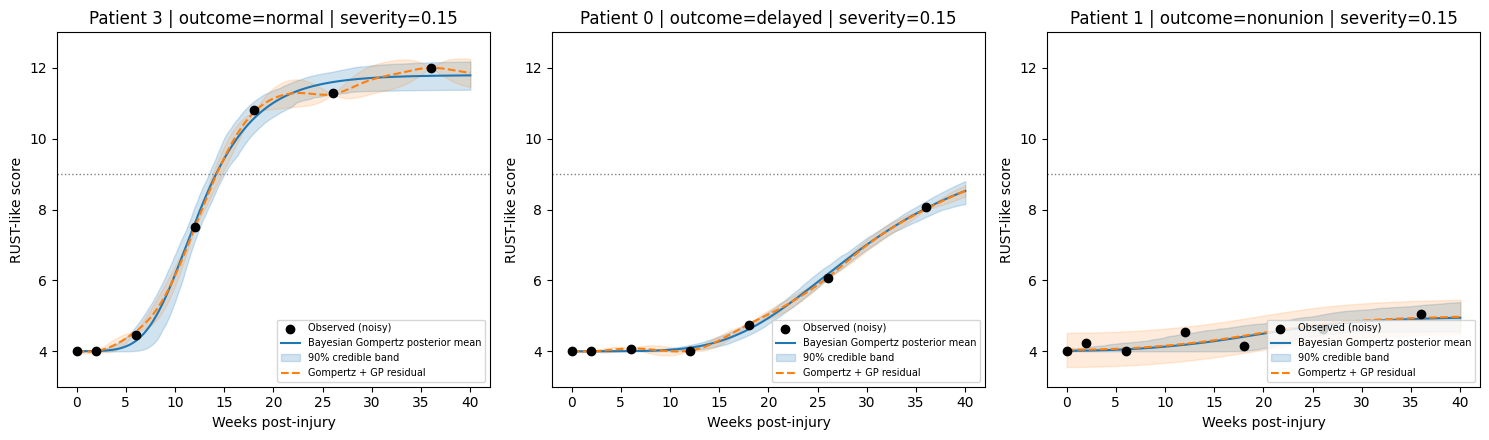

In [ ]:
import matplotlib.pyplot as plt

examples = []
for cls in ["normal", "delayed", "nonunion"]:
    matches = df[df["outcome_class"] == cls]
    if len(matches) > 0:
        examples.append(matches["patient_id"].iloc[0])

fig, axes = plt.subplots(1, len(examples), figsize=(5 * len(examples), 4.5))
if len(examples) == 1:
    axes = [axes]
for ax, pid in zip(axes, examples):
    fit_and_plot_patient(df, pid, ax)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "bayesian_gp_healing_examples.png")
plt.savefig(fig_path, dpi=150)
print(f"Saved figure to {fig_path}")
plt.show()

## 7. Download outputs

Colab session storage is temporary — download these before the session ends, or mount Google Drive and copy the `outputs/`
folder there.

**Reminder:** the longitudinal dataset here is a literature-calibrated *simulation* conditioned on real severity features
extracted from your dataset — it is not real patient healing data. State this explicitly in any write-up.

In [ ]:
import sys
if "google.colab" in sys.modules:
    from google.colab import files
    for fn in os.listdir(OUTPUT_DIR):
        files.download(os.path.join(OUTPUT_DIR, fn))
else:
    print("Not running in Colab - files are already saved locally in the 'outputs/' folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>